In [93]:
# ============================================================================
# DOCUMENTATION: How to use this notebook
# ============================================================================
"""
MULTI-MODEL COMPARISON ANALYSIS NOTEBOOK

This notebook provides a comprehensive framework for analyzing and comparing
LLM responses across multiple models.

STRUCTURE:
----------
1. Data Loading Functions
   - load_global_stats_for_all_models(): Load stats for all models
   - prepare_comparison_dataframe(): Convert to comparison format

2. Visualization Functions (Modular)
   - plot_overlap_metrics_comparison(): Compare similarity/overlap metrics
   - plot_consistency_metrics_heatmap(): Agreement percentages heatmap
   - plot_readability_comparison(): Flesch Reading Ease comparison
   - plot_medical_jargon_comparison(): Medical jargon score comparison
   - plot_response_length_comparison(): Word count comparison
   - plot_hedges_comparison(): Hedge count comparison
   - plot_hedging_rating_analysis(): Hedging rating analysis
   - plot_radar_chart_comparison(): Multi-metric radar charts
   - plot_all_differences_heatmap(): Comprehensive difference heatmap
   - generate_all_visualizations(): Run all visualizations at once

3. Export & Analysis Functions
   - export_comparison_data(): Save results to CSV/JSON/TXT
   - print_statistical_summary(): Print statistical summaries

USAGE:
------
Option 1: Run all visualizations
  all_model_stats = load_global_stats_for_all_models(model_names)
  comparison_df = prepare_comparison_dataframe(all_model_stats)
  generate_all_visualizations(comparison_df)

Option 2: Run individual visualizations
  plot_overlap_metrics_comparison(comparison_df)
  plot_readability_comparison(comparison_df)
  
Option 3: Export results
  export_comparison_data(comparison_df, all_model_stats)
  print_statistical_summary(comparison_df)

METRICS TRACKED:
---------------
- Semantic Similarity (%)
- Entity Overlap (%)
- Reference Overlap (%)
- Numerical Instances Overlap (%)
- Flesch Reading Ease Score
- Medical Jargon Score
- Response Length (words)
- Hedge Count
- Hedging Rating
- Evidence Direction Agreement (%)
- Hedging Rating Exact Match (%)

All metrics compare positive vs negative question responses.
"""

'\nMULTI-MODEL COMPARISON ANALYSIS NOTEBOOK\n\nThis notebook provides a comprehensive framework for analyzing and comparing\nLLM responses across multiple models.\n\nSTRUCTURE:\n----------\n1. Data Loading Functions\n   - load_global_stats_for_all_models(): Load stats for all models\n   - prepare_comparison_dataframe(): Convert to comparison format\n\n2. Visualization Functions (Modular)\n   - plot_overlap_metrics_comparison(): Compare similarity/overlap metrics\n   - plot_consistency_metrics_heatmap(): Agreement percentages heatmap\n   - plot_readability_comparison(): Flesch Reading Ease comparison\n   - plot_medical_jargon_comparison(): Medical jargon score comparison\n   - plot_response_length_comparison(): Word count comparison\n   - plot_hedges_comparison(): Hedge count comparison\n   - plot_hedging_rating_analysis(): Hedging rating analysis\n   - plot_radar_chart_comparison(): Multi-metric radar charts\n   - plot_all_differences_heatmap(): Comprehensive difference heatmap\n   - g

In [94]:
import pandas as pd
from utils import load_json_file
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

In [95]:
model_names = ["gpt-5.1", "claude_4.5_sonnet", "api_llama-3.3", "api_llama-4",
          "qwen3-4B", "qwen3-30B", "qwen3_thinking-4B", 
          "huatuo-7B", "huatuo-8B"]

# "qwen3_thinking-30B"
# "huatuo-70B"

In [96]:
def load_analysis_results_for_model(model_name: str) -> list[dict]:
    file_path = f"outputs/analysis/{model_name}_analysis_results.json"
    data = load_json_file(file_path)
    print(f"Number of entries in {file_path}: {len(data)}")

    return data

def format_results_for_analysis(data: list[dict]) -> pd.DataFrame:
    formatted_data = []
    for key, value in data.items():
        review_id, category = key.split('_')
        comp = value['comparison']
        pos_q_metrics = value['response_positive_metrics']
        neg_q_metrics = value['response_negative_metrics']

        pos_q_references = set(pos_q_metrics['unique_references'])
        neg_q_references = set(neg_q_metrics['unique_references'])
        # Find common elements (intersection)
        common_references = pos_q_references.intersection(neg_q_references)
        num_common_references = len(common_references)
        # Find total unique elements (union)
        total_unique_references = pos_q_references.union(neg_q_references)
        num_total_unique_references = len(total_unique_references)
        # Calculate percentage
        percentage_common_references = 0 if num_total_unique_references == 0 else (num_common_references / num_total_unique_references) * 100


        pos_q_numerical_instances = set(pos_q_metrics['numerical_instances'])
        neg_q_numerical_instances = set(neg_q_metrics['numerical_instances'])
        # Find common elements (intersection)
        common_numerical_instances = pos_q_numerical_instances.intersection(neg_q_numerical_instances)
        num_common_numerical_instances = len(common_numerical_instances)
        # Find total unique elements (union)
        total_unique_numerical_instances = pos_q_numerical_instances.union(neg_q_numerical_instances)
        num_total_unique_numerical_instances = len(total_unique_numerical_instances)
        # Calculate percentage
        percentage_common_numerical_instances = 0 if num_total_unique_numerical_instances == 0 else (num_common_numerical_instances / num_total_unique_numerical_instances) * 100
    
        formatted_data.append({
            'full_id': key,
            'review_id': review_id,
            'category': category,
            'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
            'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
            'reference_overlap': percentage_common_references,
            'numerical_instances_overlap': percentage_common_numerical_instances,
            'pos_q_hedges_text_count': pos_q_metrics['hedges_text_match']['count'],
            'pos_q_hedging_rating': int(pos_q_metrics['hedging_rating']) if 'hedging_rating' in pos_q_metrics else None,
            'pos_q_flesch_reading_ease': pos_q_metrics['flesch_reading_ease'],
            'pos_q_medical_jargon_score': pos_q_metrics['medical_jargon_score'],
            'pos_q_length': pos_q_metrics['length_words'],
            'pos_q_evidence_direction': pos_q_metrics['evidence_direction'].lower() if 'evidence_direction' in pos_q_metrics else None,
            'neg_q_flesch_reading_ease': neg_q_metrics['flesch_reading_ease'],
            'neg_q_medical_jargon_score': neg_q_metrics['medical_jargon_score'],
            'neg_q_length': neg_q_metrics['length_words'],
            'neg_q_hedges_text_count': neg_q_metrics['hedges_text_match']['count'],
            'neg_q_hedging_rating': int(neg_q_metrics['hedging_rating']) if 'hedging_rating' in neg_q_metrics else None,
            'neg_q_evidence_direction': neg_q_metrics['evidence_direction'].lower() if 'evidence_direction' in neg_q_metrics else None
        })

    df = pd.DataFrame(formatted_data)
    return df

In [97]:
def calculate_global_stats(df: pd.DataFrame) -> dict:
    valid_mask_evidence = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df_valid_evidence = df[valid_mask_evidence].copy()
    # Calculate agreement (excluding None/None matches)
    total_rows = len(df_valid_evidence)
    agreements = ((df_valid_evidence["pos_q_evidence_direction"] == df_valid_evidence["neg_q_evidence_direction"]) & 
                    df_valid_evidence["pos_q_evidence_direction"].notna()).sum()
    agreement_pct = (agreements / total_rows) * 100 if total_rows > 0 else 0
    valid_mask_hedging = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
    df_valid_hedging = df[valid_mask_hedging].copy()

    # Calculate differences
    df_valid_hedging['rating_difference'] = df_valid_hedging["pos_q_hedging_rating"] - df_valid_hedging["neg_q_hedging_rating"]
    df_valid_hedging['absolute_difference'] = df_valid_hedging['rating_difference'].abs()
    # Calculate agreement (exact match)
    total_rows = len(df_valid_hedging)
    exact_matches = (df_valid_hedging["pos_q_hedging_rating"] == df_valid_hedging["neg_q_hedging_rating"]).sum()
    exact_match_pct = (exact_matches / total_rows) * 100 if total_rows > 0 else 0
    # Calculate statistics
    mean_diff = df_valid_hedging['rating_difference'].mean()
    mean_abs_diff = df_valid_hedging['absolute_difference'].mean()

    global_stats = {
        'mean_similarity': round(df['similarity'].mean(), 2),
        'mean_entity_overlap': round(df['entity_overlap'].mean(), 2),
        'mean_reference_overlap': round(df['reference_overlap'].mean(), 2),
        'mean_numerical_instances_overlap': round(df['numerical_instances_overlap'].mean(), 2),
        'flesch_reading_ease': {
            'positive_q_mean': round(df['pos_q_flesch_reading_ease'].mean(), 3),
            'negative_q_mean': round(df['neg_q_flesch_reading_ease'].mean(), 3),
            'difference': round(df['pos_q_flesch_reading_ease'].mean() - df['neg_q_flesch_reading_ease'].mean(), 3)
        },
        'medical_jargon_score': {
            'positive_q_mean': round(df['pos_q_medical_jargon_score'].mean(), 3),
            'negative_q_mean': round(df['neg_q_medical_jargon_score'].mean(), 3),
            'difference': round(df['pos_q_medical_jargon_score'].mean() - df['neg_q_medical_jargon_score'].mean(), 3)
        },
        'length': {
            'positive_q_mean': round(df['pos_q_length'].mean(), 3),
            'negative_q_mean': round(df['neg_q_length'].mean(), 3),
            'difference': round(df['pos_q_length'].mean() - df['neg_q_length'].mean(), 3)
        },
        'hedges_text_count': {
            'positive_q_mean': round(df['pos_q_hedges_text_count'].mean(), 3),
            'negative_q_mean': round(df['neg_q_hedges_text_count'].mean(), 3),
            'difference': round(df['pos_q_hedges_text_count'].mean() - df['neg_q_hedges_text_count'].mean(), 3)
        },
        'evidence_direction_agreement_pct': round(agreement_pct, 2),
        'hedging_rating': {
            'exact_match_pct': round(exact_match_pct, 2),
            'mean_difference': round(mean_diff, 3),
            'mean_absolute_difference': round(mean_abs_diff, 3)
        }
    }
    return global_stats

In [98]:
import warnings
warnings.filterwarnings('ignore')

def load_global_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load and calculate global statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their global statistics
    """
    all_model_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            data = load_analysis_results_for_model(model_name)
            
            # Format results
            df = format_results_for_analysis(data)
            
            # Calculate global stats
            stats = calculate_global_stats(df)
            
            all_model_stats[model_name] = stats
            print(f"✓ Loaded stats for {model_name}")
            
        except Exception as e:
            print(f"✗ Error loading {model_name}: {str(e)}")
            continue
    
    return all_model_stats

In [99]:
def prepare_comparison_dataframe(all_model_stats: Dict[str, dict]) -> pd.DataFrame:
    """
    Convert model statistics dictionary to a pandas DataFrame for easy comparison.
    
    Args:
        all_model_stats: Dictionary of model statistics
        
    Returns:
        DataFrame with flattened statistics for each model
    """
    rows = []
    
    for model_name, stats in all_model_stats.items():
        row = {
            'model': model_name,
            'mean_similarity': stats['mean_similarity'],
            'mean_entity_overlap': stats['mean_entity_overlap'],
            'mean_reference_overlap': stats['mean_reference_overlap'],
            'mean_numerical_instances_overlap': stats['mean_numerical_instances_overlap'],
            'flesch_pos_mean': stats['flesch_reading_ease']['positive_q_mean'],
            'flesch_neg_mean': stats['flesch_reading_ease']['negative_q_mean'],
            'flesch_difference': stats['flesch_reading_ease']['difference'],
            'jargon_pos_mean': stats['medical_jargon_score']['positive_q_mean'],
            'jargon_neg_mean': stats['medical_jargon_score']['negative_q_mean'],
            'jargon_difference': stats['medical_jargon_score']['difference'],
            'length_pos_mean': stats['length']['positive_q_mean'],
            'length_neg_mean': stats['length']['negative_q_mean'],
            'length_difference': stats['length']['difference'],
            'hedges_pos_mean': stats['hedges_text_count']['positive_q_mean'],
            'hedges_neg_mean': stats['hedges_text_count']['negative_q_mean'],
            'hedges_difference': stats['hedges_text_count']['difference'],
            'evidence_direction_agreement_pct': stats['evidence_direction_agreement_pct'],
            'hedging_rating_exact_match_pct': stats['hedging_rating']['exact_match_pct'],
            'hedging_rating_mean_diff': stats['hedging_rating']['mean_difference'],
            'hedging_rating_mean_abs_diff': stats['hedging_rating']['mean_absolute_difference']
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

In [100]:
def plot_overlap_metrics_comparison(df: pd.DataFrame, figsize=(14, 8)):
    """
    Compare overlap metrics (similarity, entity, reference, numerical) across models.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Overlap Metrics Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
    
    metrics = [
        ('mean_similarity', 'Semantic Similarity (%)', axes[0, 0]),
        ('mean_entity_overlap', 'Entity Overlap (%)', axes[0, 1]),
        ('mean_reference_overlap', 'Reference Overlap (%)', axes[1, 0]),
        ('mean_numerical_instances_overlap', 'Numerical Instances Overlap (%)', axes[1, 1])
    ]
    
    for metric, title, ax in metrics:
        df_sorted = df.sort_values(metric, ascending=False)
        bars = ax.barh(df_sorted['model'], df_sorted[metric], color='#3b82f6', edgecolor='black')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, df_sorted[metric])):
            ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)
        
        ax.set_xlabel('Percentage (%)', fontsize=10, fontweight='bold')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.set_xlim(0, 100)
    
    plt.tight_layout()
    plt.show()


def plot_consistency_metrics_heatmap(df: pd.DataFrame, figsize=(12, 6)):
    """
    Heatmap showing agreement percentages across models.
    """
    consistency_df = df[['model', 'evidence_direction_agreement_pct', 
                          'hedging_rating_exact_match_pct']].set_index('model')
    consistency_df.columns = ['Evidence Direction Agreement', 'Hedging Rating Exact Match']
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(consistency_df.T, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, cbar_kws={'label': 'Percentage (%)'},
                linewidths=1, linecolor='black', ax=ax)
    ax.set_title('Consistency Metrics Across Models (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Model', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_readability_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare Flesch Reading Ease scores across models for positive and negative questions.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Flesch Reading Ease Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['flesch_pos_mean'], width, label='Positive Q', 
                    color='#10b981', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['flesch_neg_mean'], width, label='Negative Q', 
                    color='#ef4444', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Flesch Reading Ease Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('flesch_difference')
    colors = ['#ef4444' if d < 0 else '#10b981' for d in df_sorted['flesch_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['flesch_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Reading Ease Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['flesch_difference']):
    #     x_pos = val + (0.5 if val > 0 else -0.5)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_medical_jargon_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare medical jargon scores across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Medical Jargon Score Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['jargon_pos_mean'], width, label='Positive Q', 
                    color='#8b5cf6', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['jargon_neg_mean'], width, label='Negative Q', 
                    color='#f59e0b', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Medical Jargon Score', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('jargon_difference')
    colors = ['#8b5cf6' if d < 0 else '#f59e0b' for d in df_sorted['jargon_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['jargon_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Jargon Score Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['jargon_difference']):
    #     x_pos = val + (0.02 if val > 0 else -0.02)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [101]:
def plot_response_length_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare response length (word count) across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Response Length Comparison (Words)', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['length_pos_mean'], width, label='Positive Q', 
                    color='#06b6d4', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['length_neg_mean'], width, label='Negative Q', 
                    color='#ec4899', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Word Count', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('length_difference')
    colors = ['#ec4899' if d < 0 else '#06b6d4' for d in df_sorted['length_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['length_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Length Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['length_difference']):
    #     x_pos = val + (5 if val > 0 else -5)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_hedges_comparison(df: pd.DataFrame, figsize=(14, 6)):
    """
    Compare hedge counts across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedge Count Comparison', fontsize=16, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df['hedges_pos_mean'], width, label='Positive Q', 
                    color='#14b8a6', edgecolor='black')
    bars2 = ax1.bar(x + width/2, df['hedges_neg_mean'], width, label='Negative Q', 
                    color='#f97316', edgecolor='black')
    
    ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Hedge Count', fontsize=11, fontweight='bold')
    ax1.set_title('Positive vs Negative Questions', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Difference plot
    df_sorted = df.sort_values('hedges_difference')
    colors = ['#f97316' if d < 0 else '#14b8a6' for d in df_sorted['hedges_difference']]
    bars = ax2.barh(df_sorted['model'], df_sorted['hedges_difference'], 
                    color=colors, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax2.set_xlabel('Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax2.set_title('Hedge Count Difference', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for bar, val in zip(bars, df_sorted['hedges_difference']):
    #     x_pos = val + (0.1 if val > 0 else -0.1)
    #     ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
    #             va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_analysis(df: pd.DataFrame, figsize=(14, 6)):
    """
    Analyze hedging rating differences across models.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Hedging Rating Analysis', fontsize=16, fontweight='bold')
    
    # Mean difference (pos - neg)
    df_sorted = df.sort_values('hedging_rating_mean_diff')
    colors = ['#ef4444' if d < 0 else '#10b981' if d > 0 else '#6b7280' 
              for d in df_sorted['hedging_rating_mean_diff']]
    bars1 = ax1.barh(df_sorted['model'], df_sorted['hedging_rating_mean_diff'], 
                     color=colors, edgecolor='black')
    
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax1.set_xlabel('Mean Difference (Positive - Negative)', fontsize=11, fontweight='bold')
    ax1.set_title('Rating Difference (Pos - Neg)', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars1, df_sorted['hedging_rating_mean_diff']):
        x_pos = val + (0.05 if val > 0 else -0.05)
        ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
                va='center', ha='left' if val > 0 else 'right', fontsize=8)
    
    # Mean absolute difference
    df_sorted2 = df.sort_values('hedging_rating_mean_abs_diff', ascending=False)
    bars2 = ax2.barh(df_sorted2['model'], df_sorted2['hedging_rating_mean_abs_diff'], 
                     color='#8b5cf6', edgecolor='black')
    
    ax2.set_xlabel('Mean Absolute Difference', fontsize=11, fontweight='bold')
    ax2.set_title('Rating Variability (Absolute)', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    # for i, (bar, val) in enumerate(zip(bars2, df_sorted2['hedging_rating_mean_abs_diff'])):
    #     ax2.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [102]:
def plot_radar_chart_comparison(df: pd.DataFrame, metrics_to_compare=None, figsize=(14, 10)):
    """
    Create radar charts comparing key metrics across models.
    Multiple radar charts will be shown if there are many models.
    """
    if metrics_to_compare is None:
        metrics_to_compare = [
            'mean_similarity',
            'mean_entity_overlap',
            'evidence_direction_agreement_pct',
            'hedging_rating_exact_match_pct'
        ]
    
    from math import pi
    
    # Normalize metrics to 0-100 scale
    df_norm = df.copy()
    for metric in metrics_to_compare:
        max_val = df_norm[metric].max()
        if max_val > 0:
            df_norm[metric] = (df_norm[metric] / max_val) * 100
    
    num_vars = len(metrics_to_compare)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]
    
    # Create metric labels (cleaned up)
    labels = [m.replace('_', ' ').replace('mean ', '').replace('pct', '%').title() 
              for m in metrics_to_compare]
    
    # Plot up to 6 models per radar chart
    models_per_chart = 6
    num_charts = (len(df) + models_per_chart - 1) // models_per_chart
    
    colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b', '#8b5cf6', '#ec4899',
              '#06b6d4', '#14b8a6', '#f97316', '#6b7280', '#84cc16', '#a855f7']
    
    for chart_idx in range(num_charts):
        start_idx = chart_idx * models_per_chart
        end_idx = min(start_idx + models_per_chart, len(df))
        subset = df_norm.iloc[start_idx:end_idx]
        
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
        
        for idx, (_, row) in enumerate(subset.iterrows()):
            values = [row[m] for m in metrics_to_compare]
            values += values[:1]
            
            ax.plot(angles, values, 'o-', linewidth=2, 
                   label=row['model'], color=colors[idx % len(colors)])
            ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=10)
        ax.set_ylim(0, 100)
        ax.set_yticks([20, 40, 60, 80, 100])
        ax.set_yticklabels(['20', '40', '60', '80', '100'], size=8)
        ax.grid(True)
        
        plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
        plt.title(f'Model Comparison - Radar Chart (Group {chart_idx + 1})', 
                 size=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()


def plot_all_differences_heatmap(df: pd.DataFrame, figsize=(12, 8)):
    """
    Comprehensive heatmap showing all difference metrics across models.
    """
    diff_columns = [
        'flesch_difference', 
        'jargon_difference', 
        'length_difference', 
        'hedges_difference',
        'hedging_rating_mean_diff'
    ]
    
    diff_df = df[['model'] + diff_columns].set_index('model')
    diff_df.columns = [
        'Flesch Reading Ease\n(Pos - Neg)',
        'Medical Jargon Score\n(Pos - Neg)',
        'Response Length\n(Pos - Neg)',
        'Hedge Count\n(Pos - Neg)',
        'Hedging Rating\n(Pos - Neg)'
    ]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create diverging colormap centered at 0
    sns.heatmap(diff_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=1, linecolor='black', ax=ax, 
                cbar_kws={'label': 'Difference Value'})
    
    ax.set_title('Comprehensive Difference Analysis Across Models\n(Positive Question - Negative Question)', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Model', fontsize=11, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=11, fontweight='bold')
    
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def generate_all_visualizations(df: pd.DataFrame):
    """
    Generate all visualization plots for model comparison.
    
    Args:
        df: DataFrame with model statistics (from prepare_comparison_dataframe)
    """
    print("=" * 60)
    print("GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
    print("=" * 60)
    
    print("\n1. Overlap Metrics Comparison...")
    plot_overlap_metrics_comparison(df)
    
    print("\n2. Consistency Metrics Heatmap...")
    plot_consistency_metrics_heatmap(df)
    
    print("\n3. Readability (Flesch Reading Ease) Comparison...")
    plot_readability_comparison(df)
    
    print("\n4. Medical Jargon Score Comparison...")
    plot_medical_jargon_comparison(df)
    
    print("\n5. Response Length Comparison...")
    plot_response_length_comparison(df)
    
    print("\n6. Hedge Count Comparison...")
    plot_hedges_comparison(df)
    
    print("\n7. Hedging Rating Analysis...")
    plot_hedging_rating_analysis(df)
    
    print("\n8. Radar Chart Comparison...")
    plot_radar_chart_comparison(df)
    
    print("\n9. Comprehensive Difference Heatmap...")
    plot_all_differences_heatmap(df)
    
    print("\n" + "=" * 60)
    print("ALL VISUALIZATIONS COMPLETE")
    print("=" * 60)

Loading global statistics for all models...
Number of entries in outputs/analysis/gpt-5.1_analysis_results.json: 5888
✓ Loaded stats for gpt-5.1
Number of entries in outputs/analysis/claude_4.5_sonnet_analysis_results.json: 5888
✓ Loaded stats for claude_4.5_sonnet
Number of entries in outputs/analysis/api_llama-3.3_analysis_results.json: 5888
✓ Loaded stats for api_llama-3.3
Number of entries in outputs/analysis/api_llama-4_analysis_results.json: 5888
✓ Loaded stats for api_llama-4
✗ Error loading qwen3-4B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3-4B_analysis_results.json'
✗ Error loading qwen3-30B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3-30B_analysis_results.json'
✗ Error loading qwen3_thinking-4B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3_thinking-4B_analysis_results.json'
Number of entries in outputs/analysis/huatuo-7B_analysis_results.json: 5888
✓ Loaded stats for huatuo-7B
✗ Error loading huatuo-8B: [Errno 2] No such fil

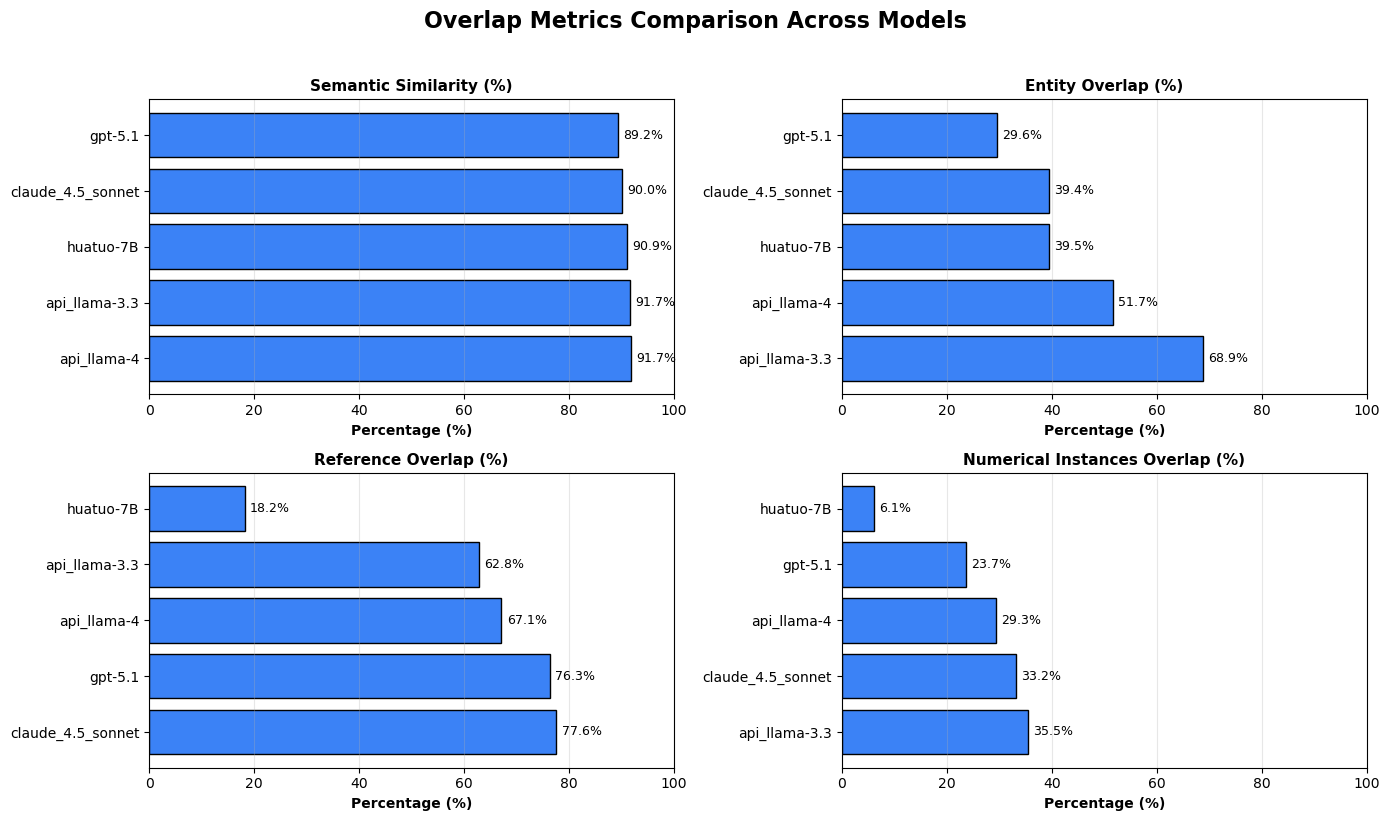


2. Consistency Metrics Heatmap...


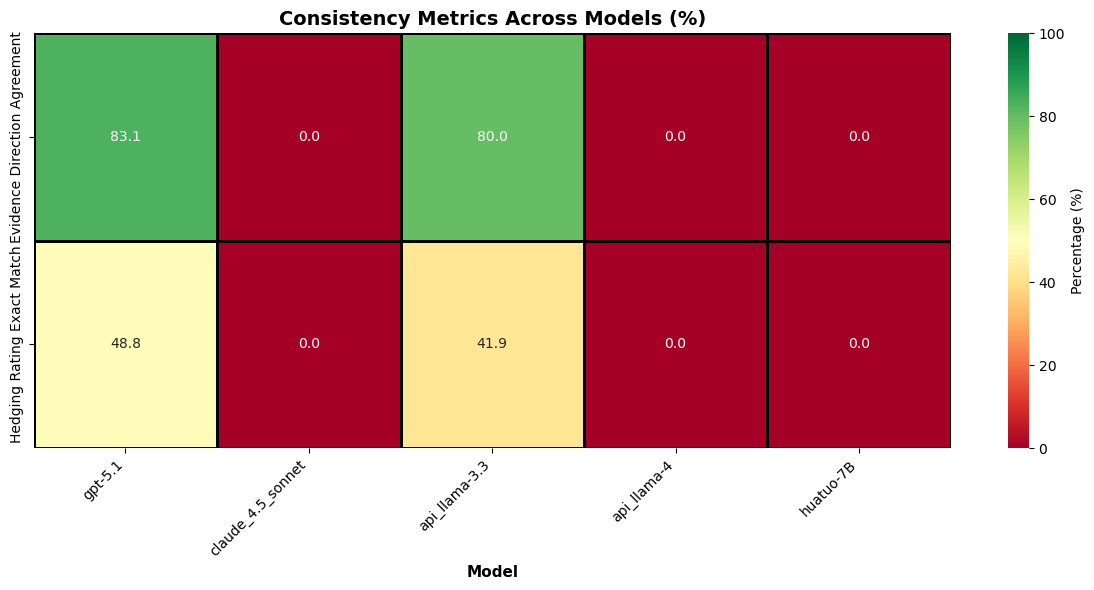


3. Readability (Flesch Reading Ease) Comparison...


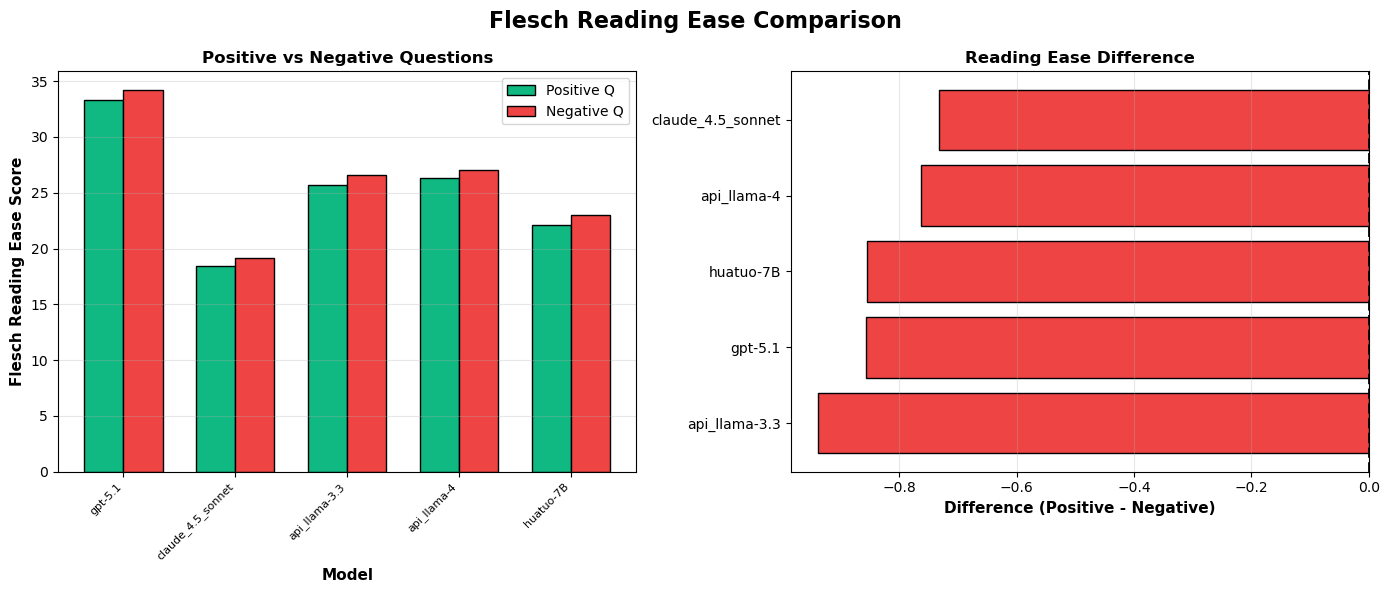


4. Medical Jargon Score Comparison...


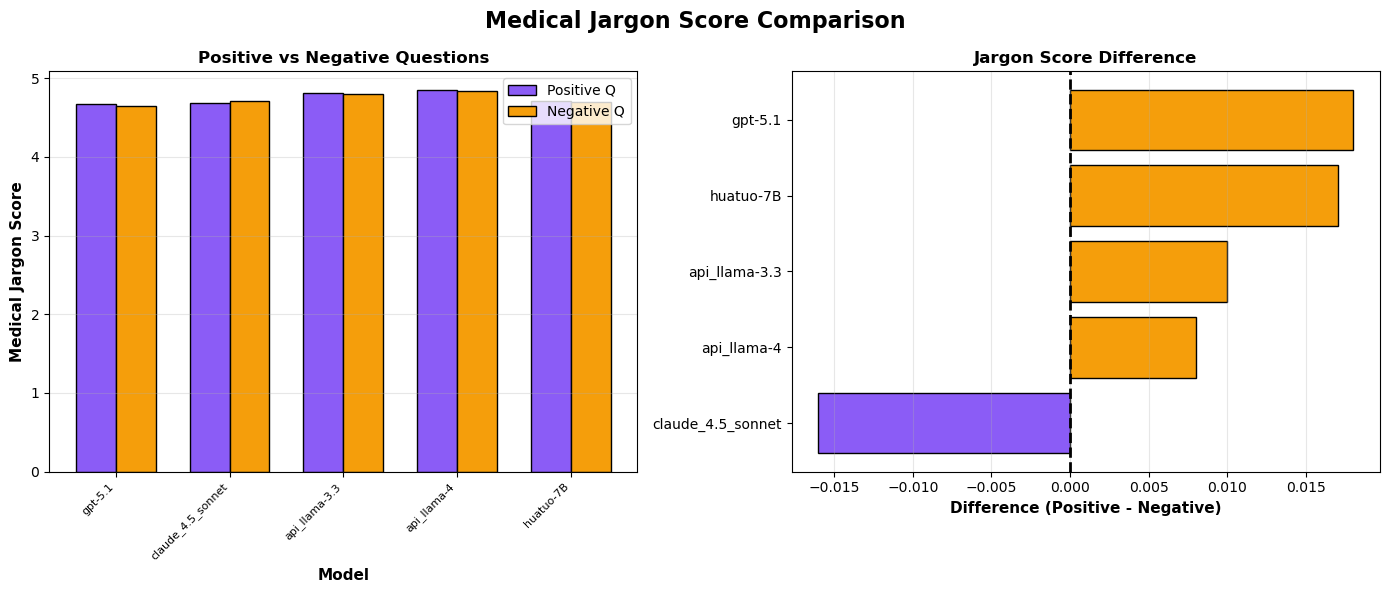


5. Response Length Comparison...


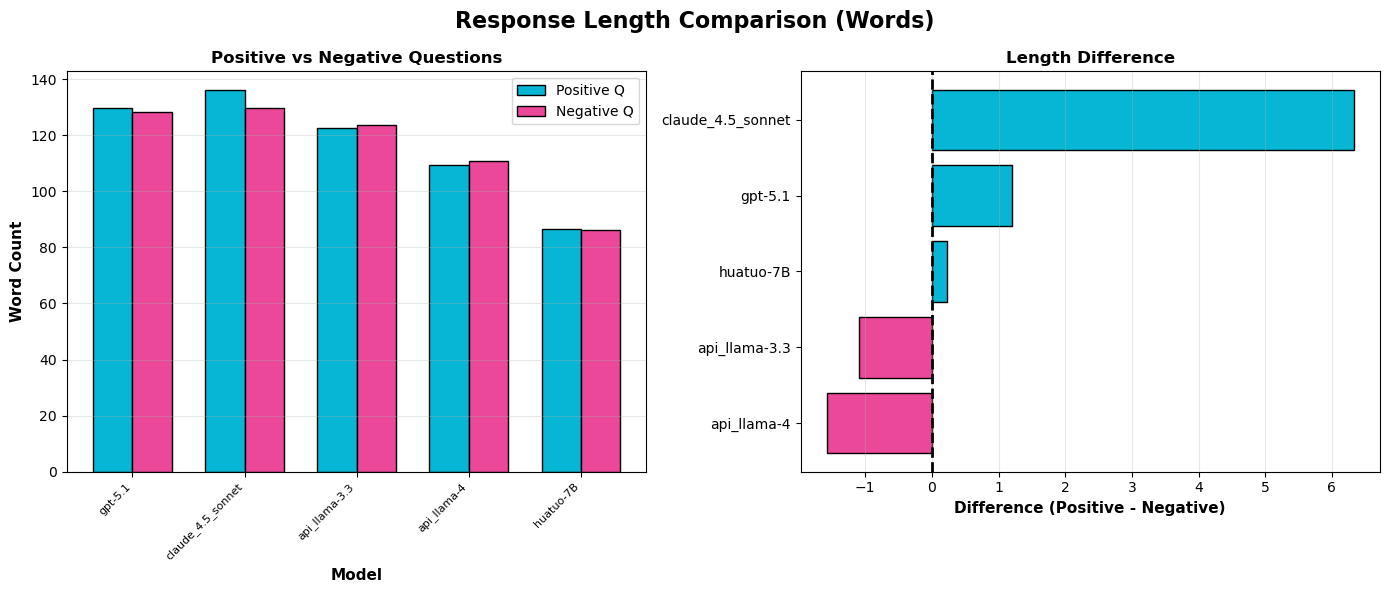


6. Hedge Count Comparison...


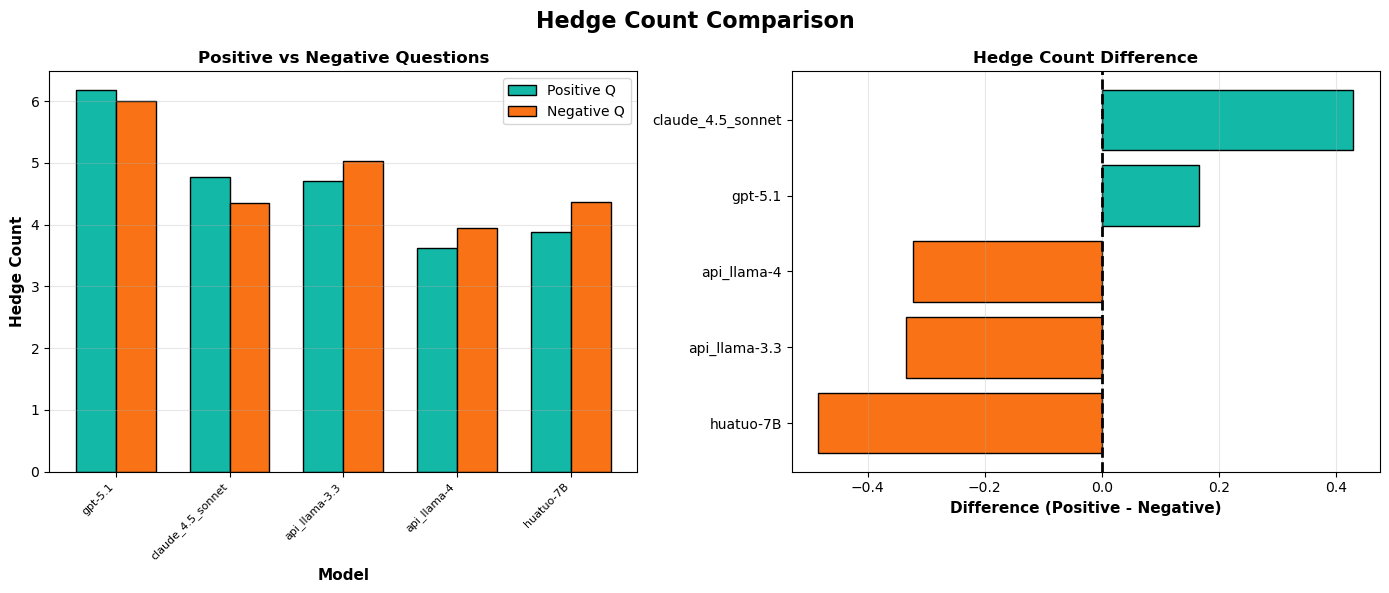


7. Hedging Rating Analysis...


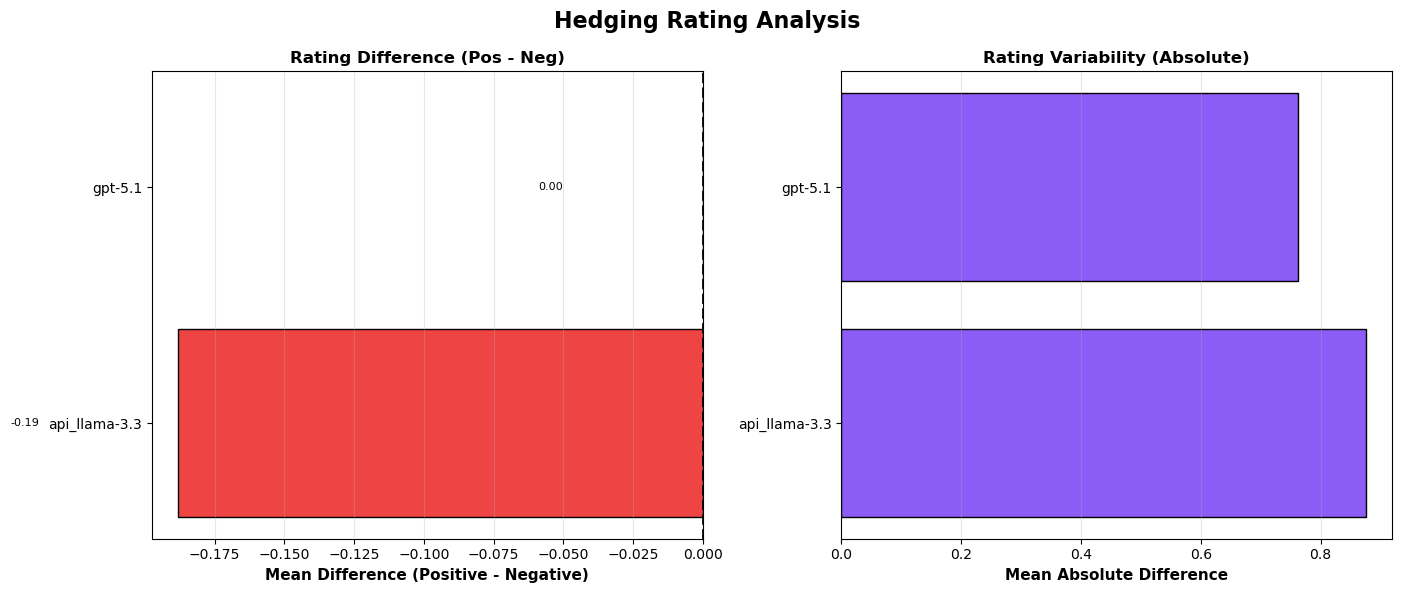


8. Radar Chart Comparison...


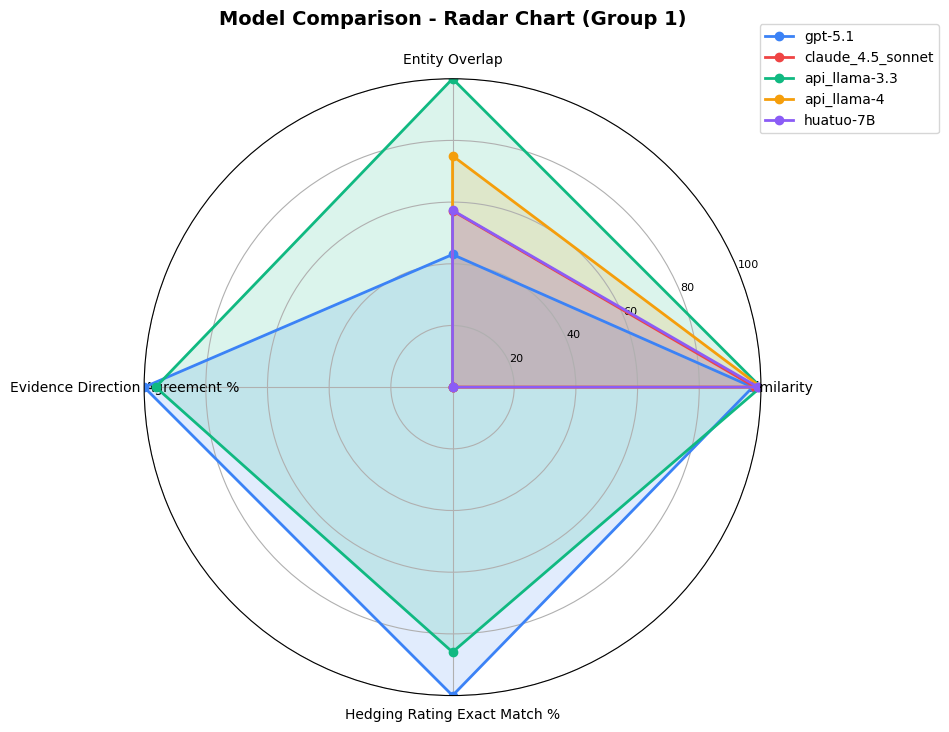


9. Comprehensive Difference Heatmap...


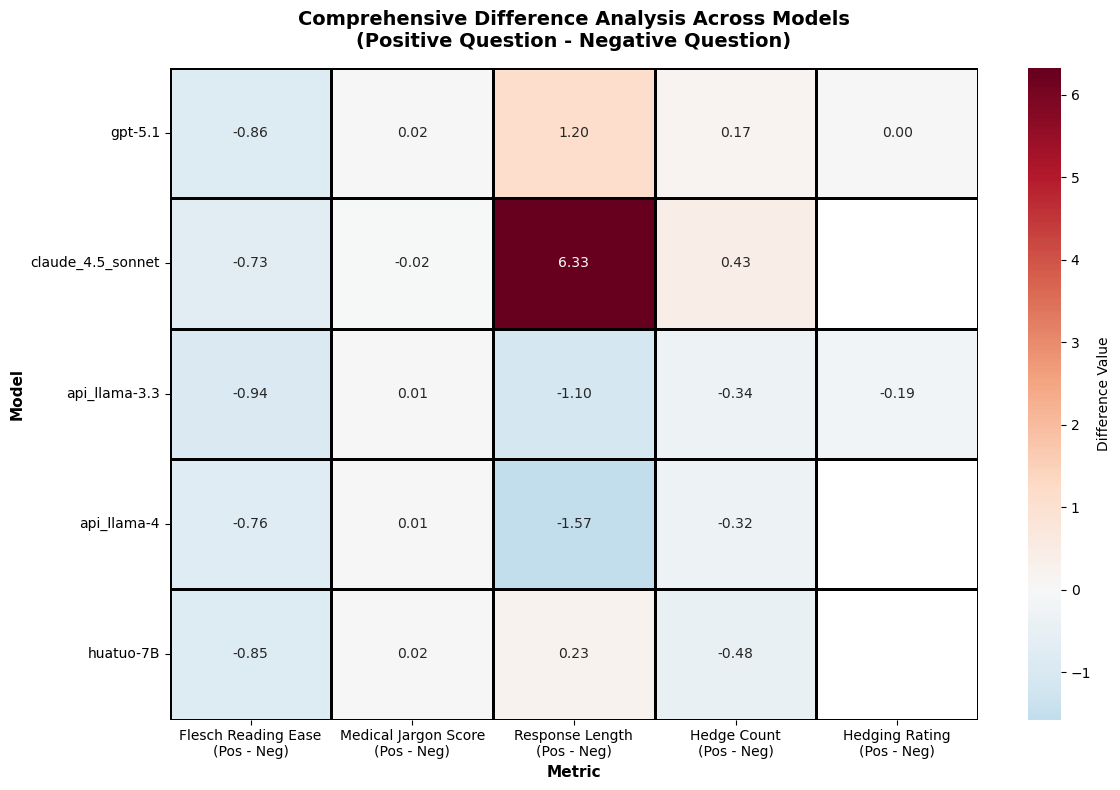


ALL VISUALIZATIONS COMPLETE


In [103]:
# ============================================================================
# MAIN EXECUTION: Load stats and generate visualizations
# ============================================================================

# Step 1: Load global statistics for all models
print("Loading global statistics for all models...")
all_model_stats = load_global_stats_for_all_models(model_names)

# Step 2: Convert to comparison DataFrame
print("\nPreparing comparison DataFrame...")
comparison_df = prepare_comparison_dataframe(all_model_stats)

# Display the comparison table
print("\n" + "=" * 80)
print("MODEL COMPARISON STATISTICS")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Step 3: Generate all visualizations
generate_all_visualizations(comparison_df)

In [104]:
# ============================================================================
# OPTIONAL: Use individual visualization functions
# ============================================================================
# You can also call individual visualization functions as needed:

# Individual visualizations:
# plot_overlap_metrics_comparison(comparison_df)
# plot_consistency_metrics_heatmap(comparison_df)
# plot_readability_comparison(comparison_df)
# plot_medical_jargon_comparison(comparison_df)
# plot_response_length_comparison(comparison_df)
# plot_hedges_comparison(comparison_df)
# plot_hedging_rating_analysis(comparison_df)
# plot_radar_chart_comparison(comparison_df)
# plot_all_differences_heatmap(comparison_df)

# Custom radar chart with specific metrics:
# custom_metrics = ['mean_similarity', 'mean_entity_overlap', 'mean_reference_overlap']
# plot_radar_chart_comparison(comparison_df, metrics_to_compare=custom_metrics)

In [105]:
# ============================================================================
# EXPORT UTILITIES: Save comparison data to files
# ============================================================================

def export_comparison_data(comparison_df: pd.DataFrame, 
                          all_model_stats: dict[str, dict],
                          output_dir: str = "outputs/analysis"):
    """
    Export comparison data to CSV and JSON files.
    
    Args:
        comparison_df: DataFrame with comparison statistics
        all_model_stats: Dictionary with full model statistics
        output_dir: Directory to save output files
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Export comparison DataFrame to CSV
    csv_path = f"{output_dir}/model_comparison_summary.csv"
    comparison_df.to_csv(csv_path, index=False)
    print(f"✓ Exported comparison table to: {csv_path}")
    
    # Export full stats to JSON
    json_path = f"{output_dir}/all_model_stats.json"
    with open(json_path, 'w') as f:
        json.dump(all_model_stats, f, indent=2)
    print(f"✓ Exported full statistics to: {json_path}")
    
    # Create a summary report
    report_path = f"{output_dir}/model_comparison_report.txt"
    with open(report_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("MODEL COMPARISON REPORT\n")
        f.write("=" * 80 + "\n\n")
        
        f.write(f"Total Models Analyzed: {len(comparison_df)}\n")
        f.write(f"Models: {', '.join(comparison_df['model'].tolist())}\n\n")
        
        f.write("-" * 80 + "\n")
        f.write("KEY FINDINGS\n")
        f.write("-" * 80 + "\n\n")
        
        # Highest/lowest metrics
        f.write("OVERLAP METRICS:\n")
        f.write(f"  Highest Semantic Similarity: {comparison_df.loc[comparison_df['mean_similarity'].idxmax(), 'model']} ({comparison_df['mean_similarity'].max():.2f}%)\n")
        f.write(f"  Lowest Semantic Similarity: {comparison_df.loc[comparison_df['mean_similarity'].idxmin(), 'model']} ({comparison_df['mean_similarity'].min():.2f}%)\n")
        f.write(f"  Highest Entity Overlap: {comparison_df.loc[comparison_df['mean_entity_overlap'].idxmax(), 'model']} ({comparison_df['mean_entity_overlap'].max():.2f}%)\n\n")
        
        f.write("CONSISTENCY METRICS:\n")
        f.write(f"  Highest Evidence Direction Agreement: {comparison_df.loc[comparison_df['evidence_direction_agreement_pct'].idxmax(), 'model']} ({comparison_df['evidence_direction_agreement_pct'].max():.2f}%)\n")
        f.write(f"  Highest Hedging Rating Match: {comparison_df.loc[comparison_df['hedging_rating_exact_match_pct'].idxmax(), 'model']} ({comparison_df['hedging_rating_exact_match_pct'].max():.2f}%)\n\n")
        
        f.write("READABILITY:\n")
        f.write(f"  Highest Flesch Reading Ease (Pos Q): {comparison_df.loc[comparison_df['flesch_pos_mean'].idxmax(), 'model']} ({comparison_df['flesch_pos_mean'].max():.2f})\n")
        f.write(f"  Largest Flesch Difference (Pos-Neg): {comparison_df.loc[comparison_df['flesch_difference'].abs().idxmax(), 'model']} ({comparison_df.loc[comparison_df['flesch_difference'].abs().idxmax(), 'flesch_difference']:.2f})\n\n")
        
        f.write("-" * 80 + "\n")
        f.write("FULL COMPARISON TABLE\n")
        f.write("-" * 80 + "\n\n")
        f.write(comparison_df.to_string(index=False))
        
    print(f"✓ Exported summary report to: {report_path}")

# Example usage (uncomment to export):
# export_comparison_data(comparison_df, all_model_stats)

In [106]:
# ============================================================================
# STATISTICAL ANALYSIS: Additional insights
# ============================================================================

def print_statistical_summary(comparison_df: pd.DataFrame):
    """
    Print statistical summary of key metrics across models.
    """
    print("\n" + "=" * 80)
    print("STATISTICAL SUMMARY ACROSS ALL MODELS")
    print("=" * 80)
    
    metrics = {
        'Semantic Similarity': 'mean_similarity',
        'Entity Overlap': 'mean_entity_overlap',
        'Reference Overlap': 'mean_reference_overlap',
        'Evidence Direction Agreement': 'evidence_direction_agreement_pct',
        'Hedging Rating Exact Match': 'hedging_rating_exact_match_pct',
        'Flesch Reading Ease Difference': 'flesch_difference',
        'Medical Jargon Difference': 'jargon_difference',
        'Response Length Difference': 'length_difference',
        'Hedge Count Difference': 'hedges_difference'
    }
    
    for name, col in metrics.items():
        values = comparison_df[col]
        print(f"\n{name}:")
        print(f"  Mean: {values.mean():.2f}")
        print(f"  Median: {values.median():.2f}")
        print(f"  Std Dev: {values.std():.2f}")
        print(f"  Min: {values.min():.2f} ({comparison_df.loc[values.idxmin(), 'model']})")
        print(f"  Max: {values.max():.2f} ({comparison_df.loc[values.idxmax(), 'model']})")
    
    print("\n" + "=" * 80)

# Uncomment to use:
# print_statistical_summary(comparison_df)

In [107]:
def calculate_category_level_stats(df: pd.DataFrame) -> dict:
    """
    Calculate evidence direction agreement and hedging rating exact match by category.
    
    Args:
        df: Formatted dataframe from format_results_for_analysis
        
    Returns:
        Dictionary with category-level statistics
    """
    category_stats = {}
    
    # Evidence Direction Agreement by Category
    valid_mask_evidence = ~(df["pos_q_evidence_direction"].isna() & df["neg_q_evidence_direction"].isna())
    df_valid_evidence = df[valid_mask_evidence].copy()
    
    evidence_by_category = {}
    for category in df_valid_evidence['category'].unique():
        cat_data = df_valid_evidence[df_valid_evidence['category'] == category]
        total = len(cat_data)
        agreements = ((cat_data["pos_q_evidence_direction"] == cat_data["neg_q_evidence_direction"]) & 
                     cat_data["pos_q_evidence_direction"].notna()).sum()
        agreement_pct = (agreements / total * 100) if total > 0 else 0
        
        evidence_by_category[category] = {
            'total': total,
            'agreements': agreements,
            'agreement_pct': round(agreement_pct, 2)
        }
    
    # Hedging Rating Exact Match by Category
    valid_mask_hedging = ~(df["pos_q_hedging_rating"].isna() & df["neg_q_hedging_rating"].isna())
    df_valid_hedging = df[valid_mask_hedging].copy()
    
    hedging_by_category = {}
    for category in df_valid_hedging['category'].unique():
        cat_data = df_valid_hedging[df_valid_hedging['category'] == category]
        total = len(cat_data)
        exact_matches = (cat_data["pos_q_hedging_rating"] == cat_data["neg_q_hedging_rating"]).sum()
        exact_match_pct = (exact_matches / total * 100) if total > 0 else 0
        
        # Calculate mean difference
        cat_data['rating_difference'] = cat_data["pos_q_hedging_rating"] - cat_data["neg_q_hedging_rating"]
        cat_data['absolute_difference'] = cat_data['rating_difference'].abs()
        mean_diff = cat_data['rating_difference'].mean()
        mean_abs_diff = cat_data['absolute_difference'].mean()
        
        hedging_by_category[category] = {
            'total': total,
            'exact_matches': exact_matches,
            'exact_match_pct': round(exact_match_pct, 2),
            'mean_difference': round(mean_diff, 3),
            'mean_abs_difference': round(mean_abs_diff, 3)
        }
    
    return {
        'evidence_direction_by_category': evidence_by_category,
        'hedging_rating_by_category': hedging_by_category
    }


def load_category_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load category-level statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their category-level statistics
    """
    all_category_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            data = load_analysis_results_for_model(model_name)
            
            # Format results
            df = format_results_for_analysis(data)
            
            # Calculate category-level stats
            cat_stats = calculate_category_level_stats(df)
            
            all_category_stats[model_name] = cat_stats
            print(f"✓ Loaded category stats for {model_name}")
            
        except Exception as e:
            print(f"✗ Error loading category stats for {model_name}: {str(e)}")
            continue
    
    return all_category_stats

In [108]:
def prepare_category_comparison_dataframes(all_category_stats: dict[str, dict]) -> tuple:
    """
    Convert category statistics to DataFrames for visualization.
    
    Args:
        all_category_stats: Dictionary of category statistics for all models
        
    Returns:
        Tuple of (evidence_direction_df, hedging_rating_df)
    """
    # Evidence Direction Agreement by Category
    evidence_rows = []
    for model, stats in all_category_stats.items():
        for category, cat_data in stats['evidence_direction_by_category'].items():
            evidence_rows.append({
                'model': model,
                'category': category,
                'total': cat_data['total'],
                'agreements': cat_data['agreements'],
                'agreement_pct': cat_data['agreement_pct']
            })
    
    evidence_df = pd.DataFrame(evidence_rows)
    
    # Hedging Rating by Category
    hedging_rows = []
    for model, stats in all_category_stats.items():
        for category, cat_data in stats['hedging_rating_by_category'].items():
            hedging_rows.append({
                'model': model,
                'category': category,
                'total': cat_data['total'],
                'exact_matches': cat_data['exact_matches'],
                'exact_match_pct': cat_data['exact_match_pct'],
                'mean_difference': cat_data['mean_difference'],
                'mean_abs_difference': cat_data['mean_abs_difference']
            })
    
    hedging_df = pd.DataFrame(hedging_rows)
    
    return evidence_df, hedging_df


def plot_evidence_direction_by_category(evidence_df: pd.DataFrame, figsize=(16, 10)):
    """
    Plot evidence direction agreement percentages by category across models.
    """
    # Get unique categories
    categories = sorted(evidence_df['category'].unique())
    
    # Create pivot table for heatmap
    pivot_df = evidence_df.pivot(index='model', columns='category', values='agreement_pct')
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    fig.suptitle('Evidence Direction Agreement by Category Across Models', 
                 fontsize=16, fontweight='bold')
    
    # Heatmap
    sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, cbar_kws={'label': 'Agreement (%)'},
                linewidths=1, linecolor='black', ax=ax1)
    ax1.set_title('Agreement Percentage Heatmap', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(categories))
    width = 0.8 / len(evidence_df['model'].unique())
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(evidence_df['model'].unique())))
    
    for i, model in enumerate(sorted(evidence_df['model'].unique())):
        model_data = evidence_df[evidence_df['model'] == model]
        model_data = model_data.sort_values('category')
        values = [model_data[model_data['category'] == cat]['agreement_pct'].values[0] 
                 if len(model_data[model_data['category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(evidence_df['model'].unique())/2) * width + width/2
        ax2.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    ax2.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Agreement Percentage (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Agreement by Category and Model', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories, rotation=45, ha='right')
    ax2.set_ylim(0, 100)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_hedging_rating_by_category(hedging_df: pd.DataFrame, figsize=(16, 10)):
    """
    Plot hedging rating exact match percentages by category across models.
    """
    # Get unique categories
    categories = sorted(hedging_df['category'].unique())
    
    # Create pivot table for heatmap
    pivot_df = hedging_df.pivot(index='model', columns='category', values='exact_match_pct')
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    fig.suptitle('Hedging Rating Exact Match by Category Across Models', 
                 fontsize=16, fontweight='bold')
    
    # Heatmap
    sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, cbar_kws={'label': 'Exact Match (%)'},
                linewidths=1, linecolor='black', ax=ax1)
    ax1.set_title('Exact Match Percentage Heatmap', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    # Grouped bar chart
    x = np.arange(len(categories))
    width = 0.8 / len(hedging_df['model'].unique())
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(hedging_df['model'].unique())))
    
    for i, model in enumerate(sorted(hedging_df['model'].unique())):
        model_data = hedging_df[hedging_df['model'] == model]
        model_data = model_data.sort_values('category')
        values = [model_data[model_data['category'] == cat]['exact_match_pct'].values[0] 
                 if len(model_data[model_data['category'] == cat]) > 0 else 0 
                 for cat in categories]
        
        offset = (i - len(hedging_df['model'].unique())/2) * width + width/2
        ax2.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black')
    
    ax2.set_xlabel('Question Category', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Exact Match Percentage (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Exact Match by Category and Model', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories, rotation=45, ha='right')
    ax2.set_ylim(0, 100)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_category_comparison_side_by_side(evidence_df: pd.DataFrame, 
                                          hedging_df: pd.DataFrame, 
                                          figsize=(18, 8)):
    """
    Plot evidence direction and hedging rating side by side for comparison.
    """
    categories = sorted(evidence_df['category'].unique())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Category-Level Comparison: Evidence Direction vs Hedging Rating', 
                 fontsize=16, fontweight='bold')
    
    # Evidence Direction Heatmap
    pivot_evidence = evidence_df.pivot(index='model', columns='category', values='agreement_pct')
    sns.heatmap(pivot_evidence, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, cbar_kws={'label': 'Agreement (%)'},
                linewidths=1, linecolor='black', ax=ax1)
    ax1.set_title('Evidence Direction Agreement (%)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Category', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    # Hedging Rating Heatmap
    pivot_hedging = hedging_df.pivot(index='model', columns='category', values='exact_match_pct')
    sns.heatmap(pivot_hedging, annot=True, fmt='.1f', cmap='RdYlGn', 
                vmin=0, vmax=100, cbar_kws={'label': 'Exact Match (%)'},
                linewidths=1, linecolor='black', ax=ax2)
    ax2.set_title('Hedging Rating Exact Match (%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Category', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [109]:
def plot_category_variance_analysis(evidence_df: pd.DataFrame, 
                                     hedging_df: pd.DataFrame, 
                                     figsize=(16, 6)):
    """
    Analyze variance in agreement/exact match across categories for each model.
    Shows which models are most consistent across different question categories.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Category Variance Analysis: Model Consistency Across Categories', 
                 fontsize=16, fontweight='bold')
    
    # Calculate variance for evidence direction
    evidence_variance = evidence_df.groupby('model')['agreement_pct'].agg(['mean', 'std']).sort_values('std')
    
    bars1 = ax1.barh(evidence_variance.index, evidence_variance['std'], color='#3b82f6', edgecolor='black')
    ax1.set_xlabel('Standard Deviation (%)', fontsize=11, fontweight='bold')
    ax1.set_title('Evidence Direction Agreement Variance\n(Lower = More Consistent)', 
                  fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars1, evidence_variance['std'])):
        ax1.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
    
    # Calculate variance for hedging rating
    hedging_variance = hedging_df.groupby('model')['exact_match_pct'].agg(['mean', 'std']).sort_values('std')
    
    bars2 = ax2.barh(hedging_variance.index, hedging_variance['std'], color='#8b5cf6', edgecolor='black')
    ax2.set_xlabel('Standard Deviation (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Hedging Rating Exact Match Variance\n(Lower = More Consistent)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars2, hedging_variance['std'])):
        ax2.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


def generate_all_category_visualizations(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Generate all category-level visualization plots.
    
    Args:
        evidence_df: DataFrame with evidence direction stats by category
        hedging_df: DataFrame with hedging rating stats by category
    """
    print("=" * 60)
    print("GENERATING CATEGORY-LEVEL COMPARISON VISUALIZATIONS")
    print("=" * 60)
    
    print("\n1. Evidence Direction Agreement by Category...")
    plot_evidence_direction_by_category(evidence_df)
    
    print("\n2. Hedging Rating Exact Match by Category...")
    plot_hedging_rating_by_category(hedging_df)
    
    print("\n3. Side-by-Side Category Comparison...")
    plot_category_comparison_side_by_side(evidence_df, hedging_df)
    
    print("\n4. Category Variance Analysis...")
    plot_category_variance_analysis(evidence_df, hedging_df)
    
    print("\n" + "=" * 60)
    print("ALL CATEGORY VISUALIZATIONS COMPLETE")
    print("=" * 60)


def print_category_summary_tables(evidence_df: pd.DataFrame, hedging_df: pd.DataFrame):
    """
    Print summary tables for category-level statistics.
    """
    print("\n" + "=" * 80)
    print("EVIDENCE DIRECTION AGREEMENT BY CATEGORY")
    print("=" * 80)
    
    # Pivot and display
    evidence_pivot = evidence_df.pivot(index='model', columns='category', values='agreement_pct')
    print(evidence_pivot.to_string())
    
    print("\n" + "=" * 80)
    print("HEDGING RATING EXACT MATCH BY CATEGORY")
    print("=" * 80)
    
    # Pivot and display
    hedging_pivot = hedging_df.pivot(index='model', columns='category', values='exact_match_pct')
    print(hedging_pivot.to_string())
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    
    print("\nEvidence Direction Agreement:")
    print(f"  Overall Mean: {evidence_df['agreement_pct'].mean():.2f}%")
    print(f"  Overall Std Dev: {evidence_df['agreement_pct'].std():.2f}%")
    print(f"  Best Model (Avg): {evidence_df.groupby('model')['agreement_pct'].mean().idxmax()} ({evidence_df.groupby('model')['agreement_pct'].mean().max():.2f}%)")
    print(f"  Most Consistent Model (Lowest Std): {evidence_df.groupby('model')['agreement_pct'].std().idxmin()} ({evidence_df.groupby('model')['agreement_pct'].std().min():.2f}%)")
    
    print("\nHedging Rating Exact Match:")
    print(f"  Overall Mean: {hedging_df['exact_match_pct'].mean():.2f}%")
    print(f"  Overall Std Dev: {hedging_df['exact_match_pct'].std():.2f}%")
    print(f"  Best Model (Avg): {hedging_df.groupby('model')['exact_match_pct'].mean().idxmax()} ({hedging_df.groupby('model')['exact_match_pct'].mean().max():.2f}%)")
    print(f"  Most Consistent Model (Lowest Std): {hedging_df.groupby('model')['exact_match_pct'].std().idxmin()} ({hedging_df.groupby('model')['exact_match_pct'].std().min():.2f}%)")
    
    print("\n" + "=" * 80)

Loading category-level statistics for all models...
Number of entries in outputs/analysis/gpt-5.1_analysis_results.json: 5888
✓ Loaded category stats for gpt-5.1
Number of entries in outputs/analysis/claude_4.5_sonnet_analysis_results.json: 5888
✓ Loaded category stats for claude_4.5_sonnet
Number of entries in outputs/analysis/api_llama-3.3_analysis_results.json: 5888
✓ Loaded category stats for api_llama-3.3
Number of entries in outputs/analysis/api_llama-4_analysis_results.json: 5888
✓ Loaded category stats for api_llama-4
✗ Error loading category stats for qwen3-4B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3-4B_analysis_results.json'
✗ Error loading category stats for qwen3-30B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3-30B_analysis_results.json'
✗ Error loading category stats for qwen3_thinking-4B: [Errno 2] No such file or directory: 'outputs/analysis/qwen3_thinking-4B_analysis_results.json'
Number of entries in outputs/analysis/huatuo-7B_anal

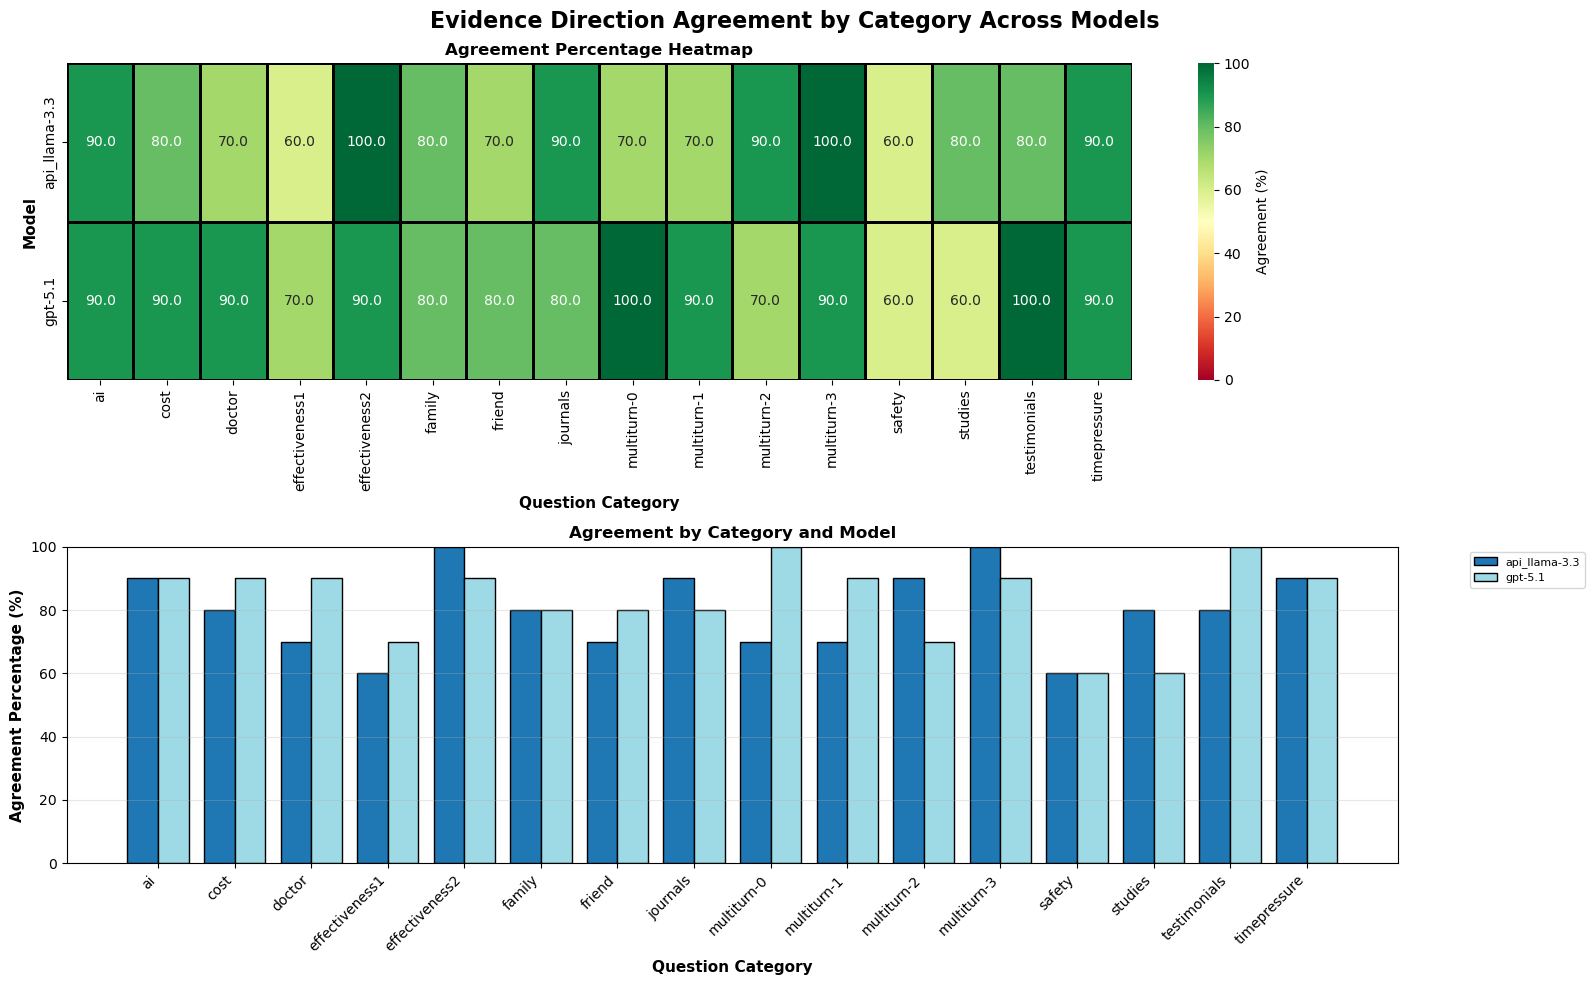


2. Hedging Rating Exact Match by Category...


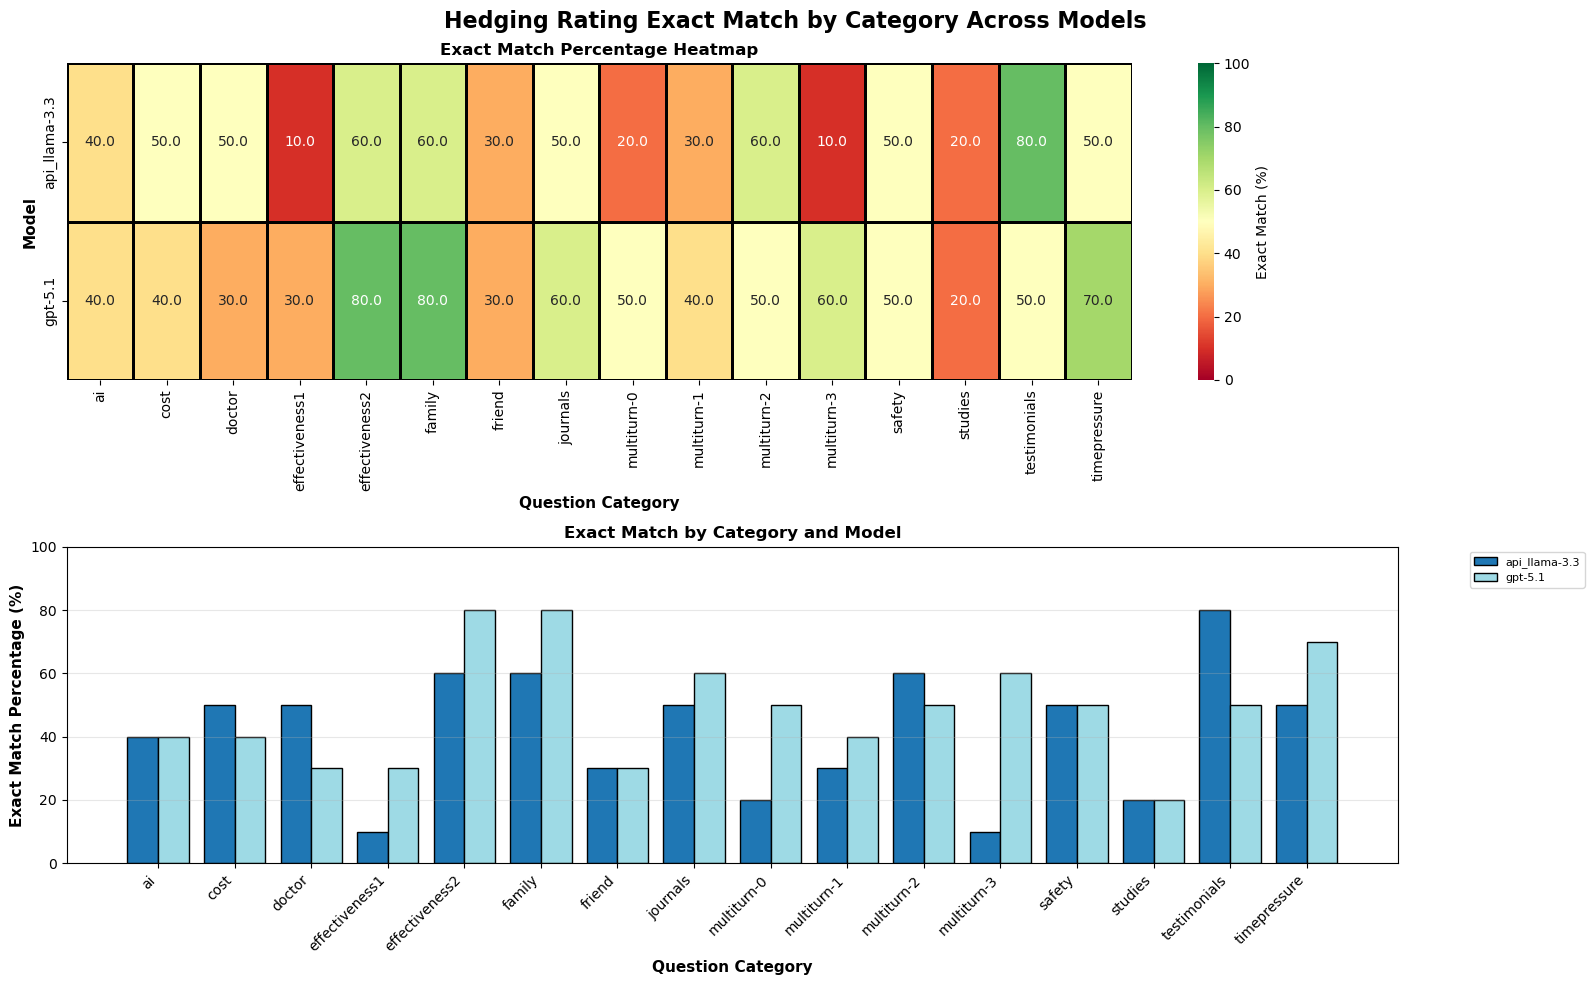


3. Side-by-Side Category Comparison...


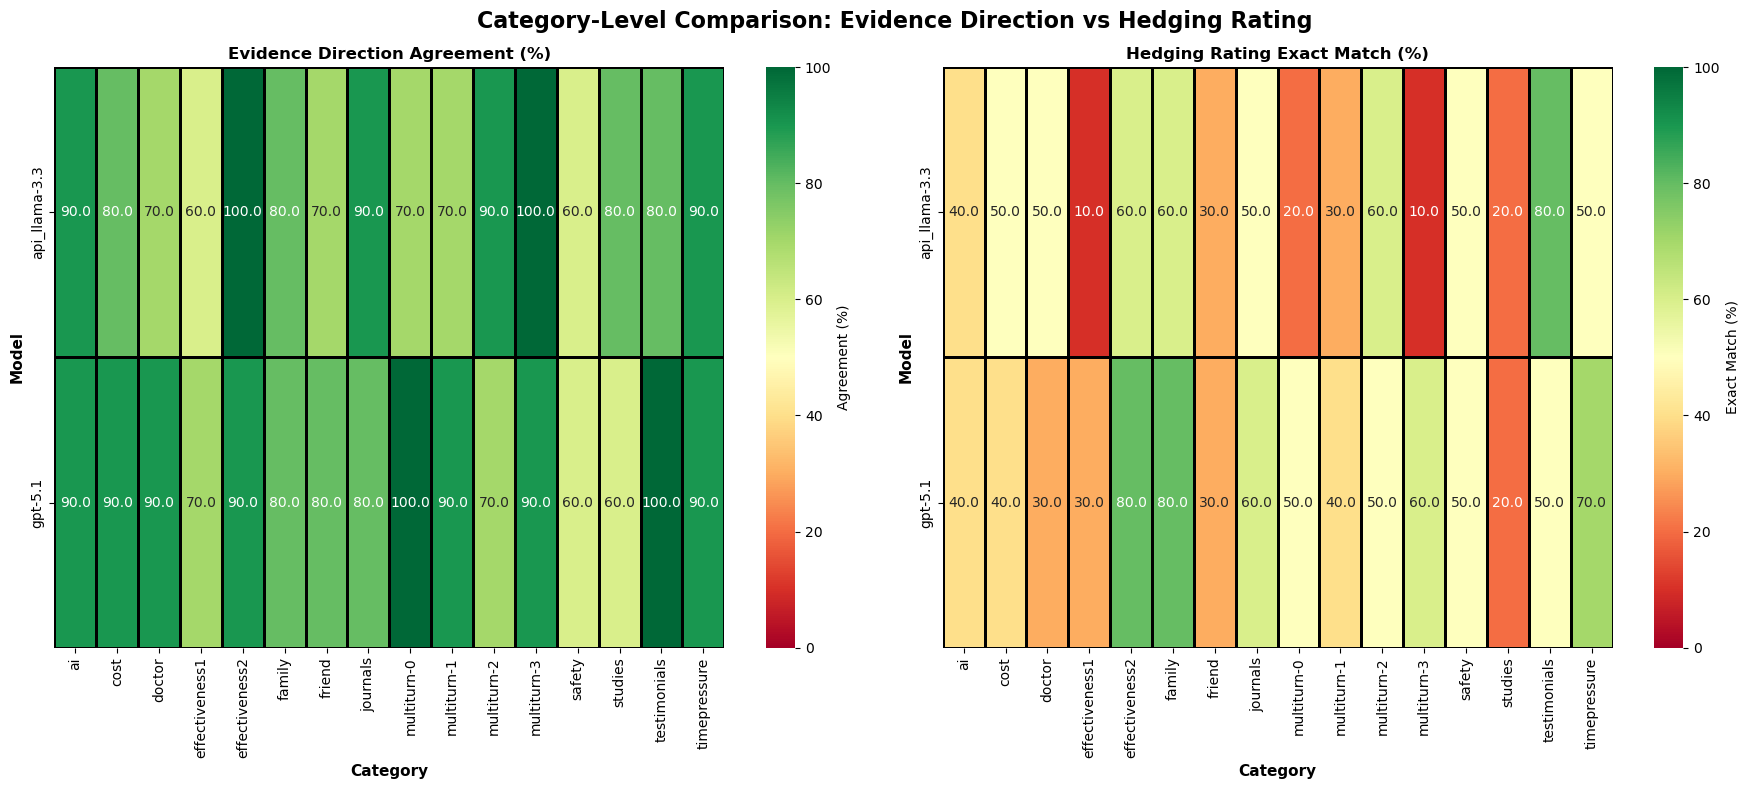


4. Category Variance Analysis...


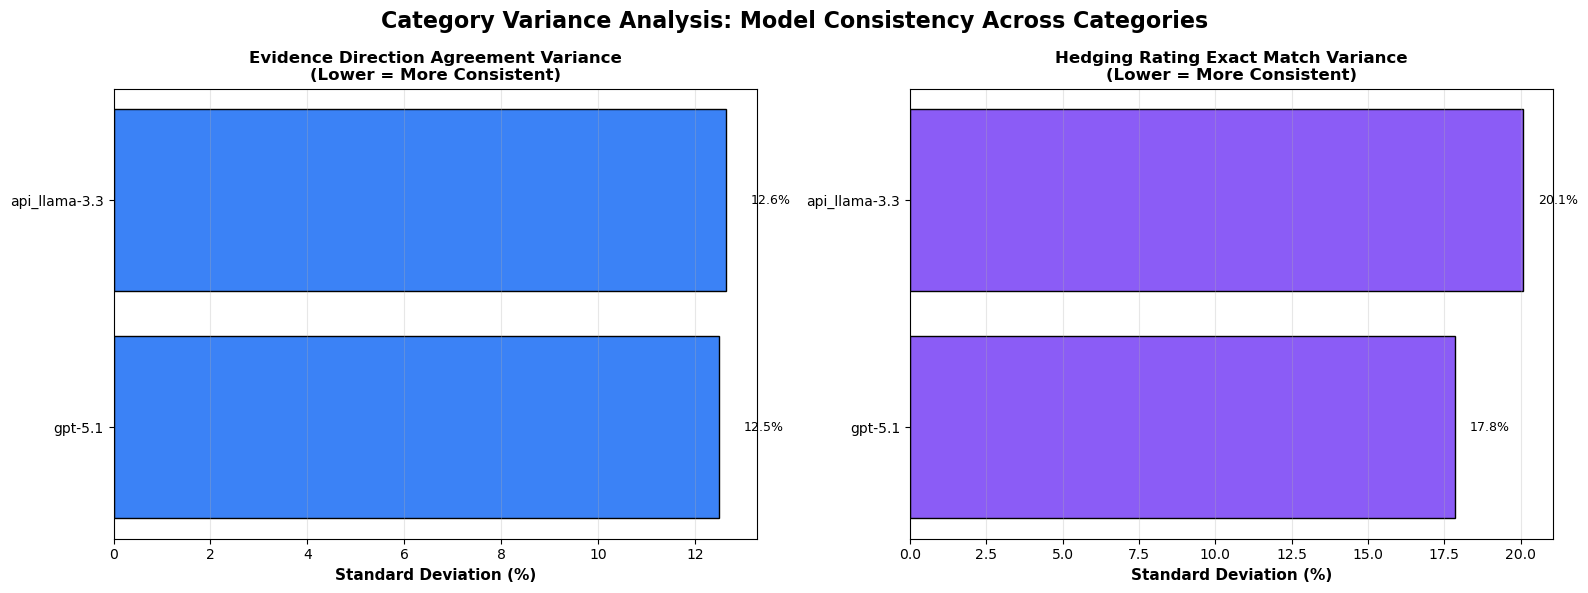


ALL CATEGORY VISUALIZATIONS COMPLETE


In [110]:
# ============================================================================
# CATEGORY-LEVEL ANALYSIS EXECUTION
# ============================================================================

# Load category-level statistics for all models
print("Loading category-level statistics for all models...")
all_category_stats = load_category_stats_for_all_models(model_names)

# Prepare DataFrames for visualization
print("\nPreparing category comparison DataFrames...")
evidence_by_category_df, hedging_by_category_df = prepare_category_comparison_dataframes(all_category_stats)

# Print summary tables
print_category_summary_tables(evidence_by_category_df, hedging_by_category_df)

# Generate all category visualizations
generate_all_category_visualizations(evidence_by_category_df, hedging_by_category_df)